# Real estate

In [30]:
import pandas as pd
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from matplotlib import pyplot as plt
from os.path import isdir
from os import makedirs
import seaborn as sns

Daten 

In [23]:
# 1. Eigene, saubere Spaltennamen definieren
col_names = [
    "ID", "transaction date", "house age", "distance public transport", 
    "convenience stores", "latitude", "longitude", "price per ping"
]

# 2. Die Daten strikt und fehlerfrei einlesen
df = pd.read_csv(
    "data/real_estate_data.csv",
    sep="~",
    skiprows=2,                       # Überspringt die Textzeilen und den alten Header
    nrows=414,                        # Stoppt exakt nach den 414 echten Datensätzen
    usecols=[0, 1, 2, 3, 4, 5, 6, 7], # Nimmt nur die echten Spalten, ignoriert Tilden-Spalten am Ende
    names=col_names                   # Nutzt unsere sauberen Namen
)

# 3. Den Fehler "fourhundredthirteen" beheben und Index setzen
df["ID"] = df["ID"].replace("fourhundredthirteen", 413)
df["ID"] = pd.to_numeric(df["ID"]).astype("Int64")

# 4. Fehlende Werte entfernen
df_cleaned = df.dropna()

# Ergebnis anzeigen
print(f"Daten erfolgreich geladen! Verbleibende Zeilen: {len(df_cleaned)}")
display(df_cleaned.head())

Daten erfolgreich geladen! Verbleibende Zeilen: 409


,ID,transaction date,house age,distance public transport,convenience stores,latitude,longitude,price per ping
0,1,2012.917,32.0,84.87882,10.0,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9.0,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5.0,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5.0,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5.0,24.97937,121.54245,43.1


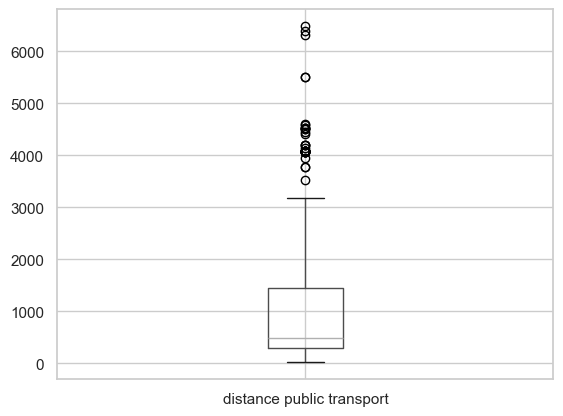

In [35]:
import matplotlib.pyplot as plt
df.boxplot(column="distance public transport")
plt.show()

In [36]:
print(df[df["distance public transport"] > 3000])

      ID  transaction date  house age  distance public transport  \
8      9          2013.500       31.7                   5512.038   
30    31          2013.500       25.9                   4519.690   
35    36          2013.500       13.9                   4079.418   
40    41          2013.000       13.6                   4082.015   
41    42          2013.500       16.8                   4066.587   
48    49          2013.417       24.2                   4605.749   
49    50          2012.667       29.4                   4510.359   
58    59          2013.500       30.3                   4510.359   
73    74          2013.167       13.8                   4082.015   
87    88          2013.583       16.9                   4066.587   
89    90          2013.500       23.0                   3947.945   
116  117          2013.000       30.9                   6396.283   
117  118          2013.000       13.6                   4197.349   
148  149          2013.500       16.4           

Statistische Zusammenfassung des Datensatzes:


,ID,transaction date,house age,distance public transport,convenience stores,latitude,longitude,price per ping
count,409.0,409.000000,409.000000,409.000000,409.000000,409.000000,409.000000,409.000000
mean,207.344743,2013.149164,17.734963,1092.211703,4.080685,24.969006,121.533309,37.738631
std,119.824794,0.282867,11.432102,1267.267326,2.945725,0.012448,0.015426,13.068853
min,1.0,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.0,2012.917000,9.000000,289.324800,1.000000,24.962990,121.527600,27.300000
50%,206.0,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.400000
75%,312.0,2013.417000,28.400000,1455.798000,6.000000,24.977460,121.543480,46.600000
max,414.0,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,78.300000


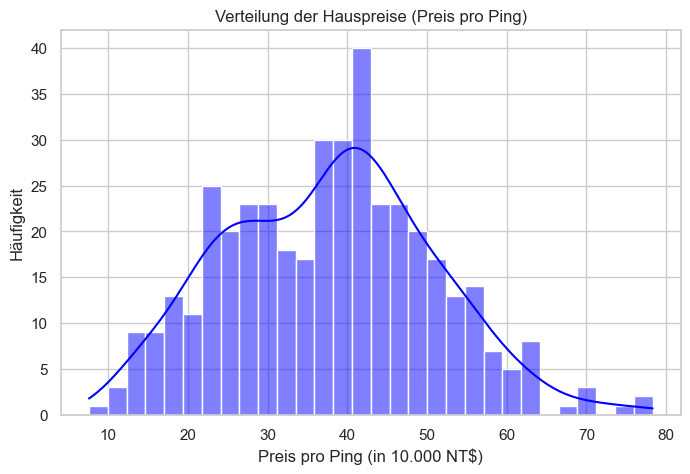

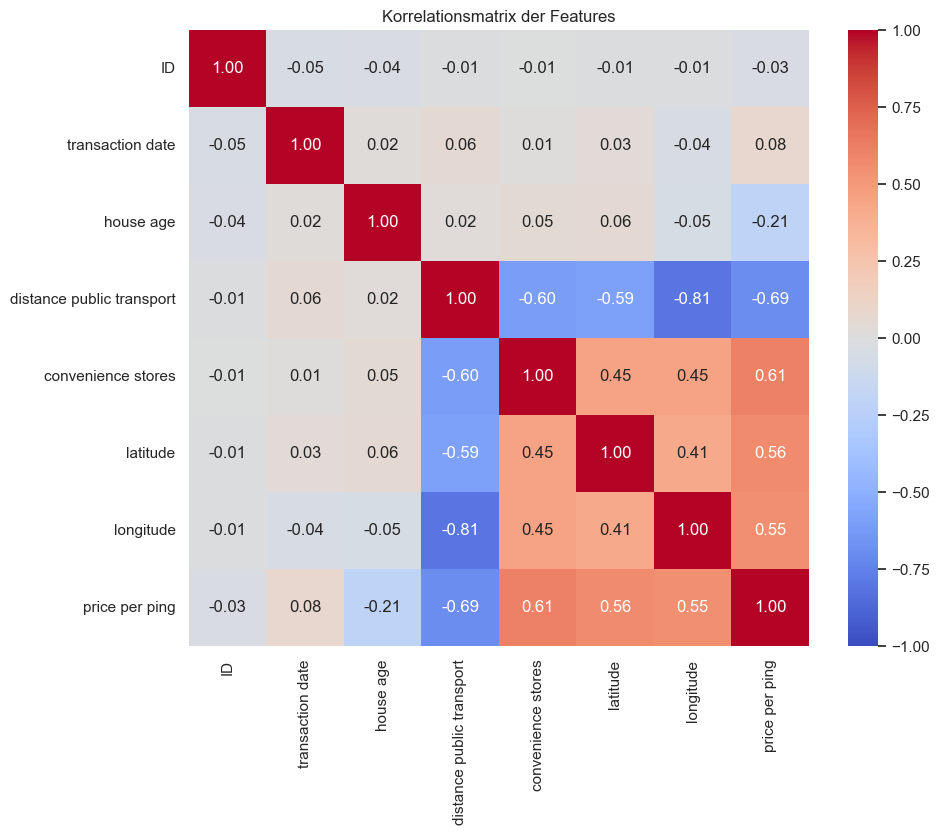

Pairplot für die wichtigsten Features:


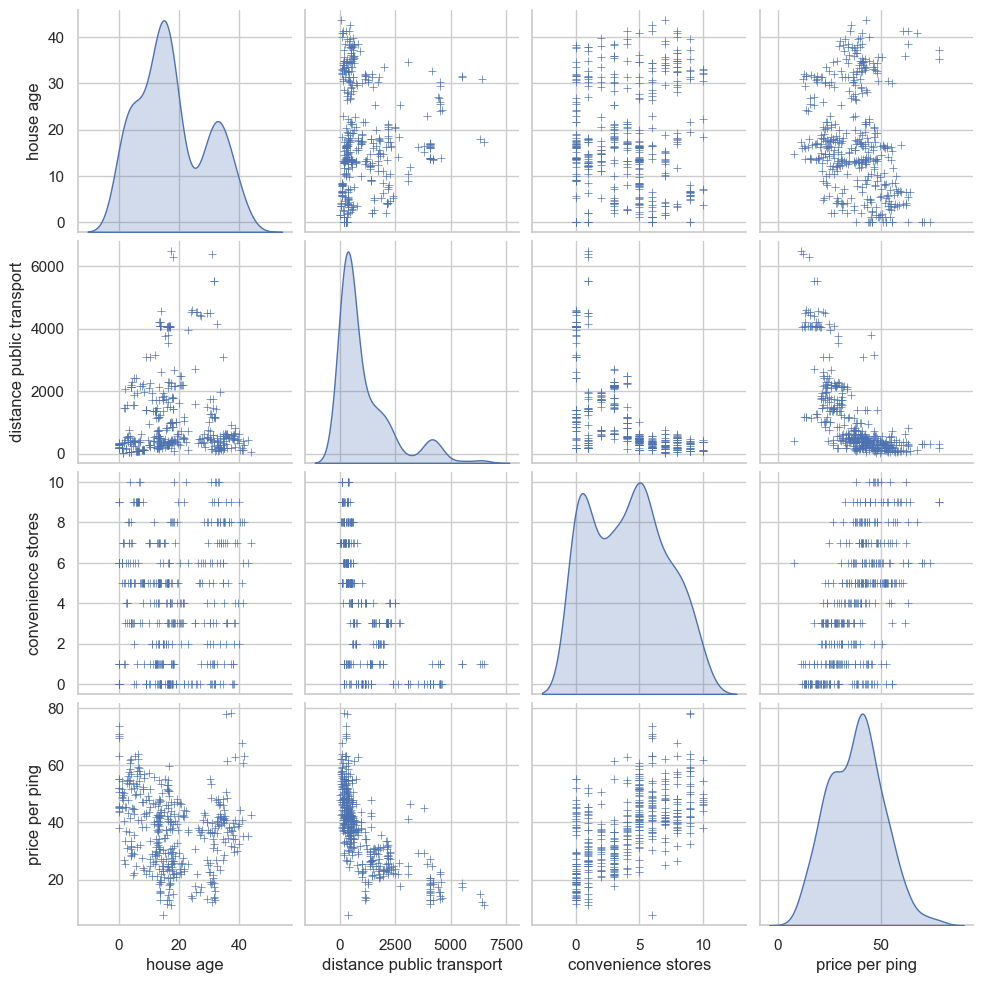

In [ ]:
sns.set_theme(style="whitegrid")

# 1. Statistische Grundauswertung
print("Statistische Zusammenfassung des Datensatzes:")
display(df_cleaned.describe())

# ---------------------------------------------------------
# 2. Verteilung der Zielvariable (Target)
# ---------------------------------------------------------
# Wie verteilen sich die Hauspreise? Gibt es extreme Ausreißer?
plt.figure(figsize=(8, 5))
sns.histplot(df_cleaned["price per ping"], kde=True, bins=30, color="blue")
plt.title("Verteilung der Hauspreise (Preis pro Ping)")
plt.xlabel("Preis pro Ping (in 10.000 NT$)")
plt.ylabel("Häufigkeit")
plt.show()

# ---------------------------------------------------------
# 3. Korrelationsanalyse (Heatmap)
# ---------------------------------------------------------
# Welche Features haben den stärksten Einfluss auf den Preis?
plt.figure(figsize=(10, 8))
correlation_matrix = df_cleaned.corr()

# Heatmap zeichnen (annot=True zeigt die genauen Werte)
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Korrelationsmatrix der Features")
plt.show()

# ---------------------------------------------------------
# 4. Detail-Analyse: Pairplot der wichtigsten Features
# ---------------------------------------------------------
# Wir schauen uns die Zusammenhänge der vielversprechendsten Features genauer an
# (Um den Plot übersichtlich zu halten, wählen wir hier eine sinnvolle Teilmenge)
important_features = ["house age", "distance public transport", "convenience stores", "price per ping"]

print("Pairplot für die wichtigsten Features:")
sns.pairplot(df_cleaned[important_features], diag_kind="kde", markers="+")
plt.show()